# Python Rule Simulation Storytelling

This notebook continues from the SQL abuse-detection analysis for campaign `CAMP_A`.

The SQL layer created the main user-level risk features and baseline suspicious-user logic. Those outputs are used here as the starting point for rule simulation.

The purpose of this notebook is to evaluate possible prevention and review rules for promotion abuse. Instead of only identifying suspicious users, this analysis compares how different rule designs perform in terms of promo-cost exposure captured, review workload, and low-score user impact.

Because the dataset does not include confirmed fraud labels, the results should be interpreted as a risk-prioritization and decision-support framework, not as confirmed fraud classification.

## Business Question

The main question for this notebook is:

> Which prevention or manual-review rule gives the best balance between promo-cost exposure captured, review workload, and low-score user impact?

A useful rule should not simply flag the largest number of users. A practical rule should capture meaningful promo exposure while keeping the review list manageable and avoiding excessive impact on users with weaker baseline risk signals.

In this notebook:

- strict rules are expected to produce smaller review lists with stronger evidence
- balanced rules are expected to support high-priority review or controlled blocking tests
- broad rules are expected to support monitoring, but may be too wide for direct action
- low-score impact is used as an over-flagging proxy, not as a confirmed error rate

## Required SQL Handoff Files

Export these from SQL before running the notebook:

| File | Required | Purpose |
|---|---:|---|
| `selected_campaign_user_scored_features.csv` | Yes | One row per selected-campaign user with features, scores, risk tier, and reason text from SQL section C |
| `suspicious_users_full.csv` | Optional | SQL final suspicious-user output, useful for reconciliation |
| `abuse_impact_summary.csv` | Optional | SQL campaign impact summary, useful for reconciliation |
| `rule_simulation_summary.csv` | Optional | SQL first rule-simulation summary, useful for comparison |

Expected folder:

```text
data/output/
```

Notebook-generated outputs will be written to:

```text
data/output/python_rule_simulation/
```

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

# Make paths work whether the notebook is opened from /notebook or project root.
CURRENT = Path.cwd()
PROJECT_ROOT = CURRENT.parent if CURRENT.name.lower() == 'notebook' else CURRENT
DATA_OUTPUT = PROJECT_ROOT / 'data' / 'output'
PY_OUTPUT = DATA_OUTPUT / 'python_rule_simulation'
PY_OUTPUT.mkdir(parents=True, exist_ok=True)

files = {
    'features': DATA_OUTPUT / 'selected_campaign_user_scored_features.csv',
    'sql_suspicious': DATA_OUTPUT / 'suspicious_users_full.csv',
    'sql_impact': DATA_OUTPUT / 'abuse_impact_summary.csv',
    'sql_rule_simulation': DATA_OUTPUT / 'rule_simulation_summary.csv',
}

print('Project root:', PROJECT_ROOT)
print('Data output folder:', DATA_OUTPUT)
print('Python output folder:', PY_OUTPUT)
print('Feature file:', files['features'])

missing_required = [name for name, path in files.items() if name == 'features' and not path.exists()]
optional_missing = [name for name, path in files.items() if name != 'features' and not path.exists()]

if missing_required:
    data_ready = False
    print('\nMissing required file:')
    for name in missing_required:
        print('-', files[name])
    print('\nExport selected_campaign_user_scored_features.csv from SQL 09 before continuing.')
else:
    data_ready = True
    print('\nRequired feature file found.')

if optional_missing:
    print('\nOptional comparison files not found yet:')
    for name in optional_missing:
        print('-', files[name].name)

Project root: C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private
Data output folder: C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output
Python output folder: C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\python_rule_simulation
Feature file: C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\selected_campaign_user_scored_features.csv

Required feature file found.


## Load SQL Feature Table

The main input should be the SQL user-level feature table. It should have one row per selected-campaign user.

Minimum useful columns:

- `userID`
- `credited_campaign_discount_success_only`
- `campaign_discount_rows`
- `immediate_discount_0_1_day`
- `immediate_discount_rows_0_1_day`
- `total_invitees`
- `max_users_per_device`
- `max_users_per_ip`
- `transfer_loop_count`

If the SQL export already contains score columns, this notebook can still recompute them for consistency.

In [2]:
if data_ready:
    features = pd.read_csv(files['features'])
    print('Rows:', len(features))
    print('Columns:', len(features.columns))
    display(features.head())
else:
    features = pd.DataFrame()

Rows: 86170
Columns: 27


,userID,credited_campaign_discount_success_only,campaign_rows,campaign_discount_rows,distinct_campaign_transactions,first_campaign_time,last_campaign_time,immediate_discount_0_1_day,immediate_discount_rows_0_1_day,distinct_immediate_discount_transactions_0_1_day,...,transfer_loop_count,score_immediate_discount,score_credited_discount,score_referral,score_device,score_ip,score_transfer_loop,suspicion_score,risk_tier,reason
0,01e1bf7861c98cd8cb5c697b5430748d,1295000,32,32,32,2022-06-16 12:02:38,2022-07-01 12:00:03,0,0,0,...,36,0,3,2,1,1,2,9,High risk,"high credited campaign discount: 1295000, high..."
1,8326efb8a480124ce5541f23b9b2852e,1265000,30,30,30,2022-06-10 23:13:46,2022-06-16 13:20:00,0,0,0,...,14,0,3,2,0,0,2,7,High risk,"high credited campaign discount: 1265000, high..."
2,85b3c6baca6acc21222b83e80f1b7842,1265000,30,30,30,2022-06-09 18:32:54,2022-06-12 19:31:33,0,0,0,...,1,0,3,2,0,0,1,6,Medium risk,"high credited campaign discount: 1265000, high..."
3,dc6c92bd2754725cc0c6084220cbc249,1265000,31,31,31,2022-06-16 09:25:12,2022-06-30 18:30:06,0,0,0,...,22,0,3,2,1,1,2,9,High risk,"high credited campaign discount: 1265000, high..."
4,69e93699b697d3dccdcd1a9f3ac6e660,1255000,30,30,30,2022-06-11 19:51:15,2022-07-01 22:00:00,0,0,0,...,27,0,3,2,0,1,2,8,High risk,"high credited campaign discount: 1255000, high..."


In [3]:
if data_ready:
    required_columns = [
        'userID',
        'credited_campaign_discount_success_only',
        'campaign_discount_rows',
        'immediate_discount_0_1_day',
        'immediate_discount_rows_0_1_day',
        'total_invitees',
        'max_users_per_device',
        'max_users_per_ip',
        'transfer_loop_count',
    ]

    missing_cols = [c for c in required_columns if c not in features.columns]
    if missing_cols:
        raise ValueError(f'Missing required columns in selected_campaign_user_scored_features.csv: {missing_cols}')

    numeric_cols = [c for c in required_columns if c != 'userID']
    for col in numeric_cols:
        features[col] = pd.to_numeric(features[col], errors='coerce').fillna(0)

    features['userID'] = features['userID'].astype(str)

    duplicate_users = features['userID'].duplicated().sum()
    print('Duplicate userID rows:', duplicate_users)
    print('Distinct users:', features['userID'].nunique())
    print('Total credited campaign discount:', features['credited_campaign_discount_success_only'].sum())

Duplicate userID rows: 0
Distinct users: 86170
Total credited campaign discount: 7003955000


## Rebuild SQL Scoring Logic in Python

This section reproduces the SQL scoring thresholds so Python uses the same baseline risk framework as SQL.

The baseline score is **not a confirmed fraud label**. It is a rule-based yardstick used to:

- prioritize users for review
- create reason text for the final `result.xlsx` deliverable
- compare whether candidate rules mostly catch stronger-evidence users or many low-score users

Python then uses this baseline to run flexible rule-simulation experiments.


In [4]:
def add_sql_scores(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out['score_immediate_discount'] = np.select(
        [
            out['immediate_discount_0_1_day'] >= 1_000_000,
            (out['immediate_discount_0_1_day'] >= 500_000) & (out['immediate_discount_rows_0_1_day'] >= 10),
        ],
        [3, 2],
        default=0,
    )

    out['score_credited_discount'] = np.select(
        [
            out['credited_campaign_discount_success_only'] >= 1_000_000,
            out['credited_campaign_discount_success_only'] >= 500_000,
            out['credited_campaign_discount_success_only'] >= 100_000,
        ],
        [3, 2, 1],
        default=0,
    )

    out['score_referral'] = np.select(
        [out['total_invitees'] >= 100, out['total_invitees'] >= 20],
        [3, 2],
        default=0,
    )

    out['score_device'] = np.select(
        [out['max_users_per_device'] >= 10, out['max_users_per_device'] >= 5],
        [2, 1],
        default=0,
    )

    out['score_ip'] = np.select(
        [out['max_users_per_ip'] >= 50, out['max_users_per_ip'] >= 20],
        [2, 1],
        default=0,
    )

    out['score_transfer_loop'] = np.select(
        [out['transfer_loop_count'] >= 3, out['transfer_loop_count'] >= 1],
        [2, 1],
        default=0,
    )

    score_cols = [
        'score_immediate_discount',
        'score_credited_discount',
        'score_referral',
        'score_device',
        'score_ip',
        'score_transfer_loop',
    ]
    out['suspicion_score'] = out[score_cols].sum(axis=1)

    out['risk_tier'] = np.select(
        [out['suspicion_score'] >= 9, out['suspicion_score'] >= 6],
        ['High risk', 'Medium risk'],
        default='Review',
    )

    reason_parts = []
    reason_parts.append(np.where(
        (out['immediate_discount_0_1_day'] >= 1_000_000)
        | ((out['immediate_discount_0_1_day'] >= 500_000) & (out['immediate_discount_rows_0_1_day'] >= 10)),
        'high immediate campaign discount within 0-1 day',
        ''
    ))
    reason_parts.append(np.where(out['credited_campaign_discount_success_only'] >= 500_000,
                                 'high credited campaign discount', ''))
    reason_parts.append(np.where(
        (out['credited_campaign_discount_success_only'] >= 100_000)
        & (out['credited_campaign_discount_success_only'] < 500_000),
        'elevated credited campaign discount',
        ''
    ))
    reason_parts.append(np.where(out['total_invitees'] >= 20,
                                 'high referral count', ''))
    reason_parts.append(np.where(out['max_users_per_device'] >= 5,
                                 'shared device signal', ''))
    reason_parts.append(np.where(out['max_users_per_ip'] >= 20,
                                 'shared IP signal', ''))
    reason_parts.append(np.where(out['transfer_loop_count'] >= 1,
                                 'transfer-loop signal', ''))

    reason_df = pd.DataFrame(reason_parts).T
    out['reason'] = reason_df.apply(lambda row: ', '.join([x for x in row if x]), axis=1)

    return out

if data_ready:
    scored = add_sql_scores(features) 
    suspicious_baseline = scored[scored['suspicion_score'] >= 3].copy()

    total_users = len(scored)
    total_discount = scored['credited_campaign_discount_success_only'].sum()
    suspicious_users = len(suspicious_baseline)
    suspicious_discount = suspicious_baseline['credited_campaign_discount_success_only'].sum()

    baseline_summary = pd.DataFrame([{
        'total_scored_users': total_users,
        'total_suspicious_users': suspicious_users,
        'suspicious_user_rate_pct': suspicious_users / total_users * 100 if total_users else 0,
        'total_campaign_discount': total_discount,
        'discount_used_by_suspicious_users': suspicious_discount,
        'share_of_campaign_discount_pct': suspicious_discount / total_discount * 100 if total_discount else 0,
    }])

    display(baseline_summary)
    display(suspicious_baseline.head())
else:
    scored = pd.DataFrame()
    suspicious_baseline = pd.DataFrame()

,total_scored_users,total_suspicious_users,suspicious_user_rate_pct,total_campaign_discount,discount_used_by_suspicious_users,share_of_campaign_discount_pct
0,86170,3671,4.260183,7003955000,1887180000,26.944491


,userID,credited_campaign_discount_success_only,campaign_rows,campaign_discount_rows,distinct_campaign_transactions,first_campaign_time,last_campaign_time,immediate_discount_0_1_day,immediate_discount_rows_0_1_day,distinct_immediate_discount_transactions_0_1_day,...,transfer_loop_count,score_immediate_discount,score_credited_discount,score_referral,score_device,score_ip,score_transfer_loop,suspicion_score,risk_tier,reason
0,01e1bf7861c98cd8cb5c697b5430748d,1295000,32,32,32,2022-06-16 12:02:38,2022-07-01 12:00:03,0,0,0,...,36,0,3,2,1,1,2,9,High risk,"high credited campaign discount, high referral..."
1,8326efb8a480124ce5541f23b9b2852e,1265000,30,30,30,2022-06-10 23:13:46,2022-06-16 13:20:00,0,0,0,...,14,0,3,2,0,0,2,7,Medium risk,"high credited campaign discount, high referral..."
2,85b3c6baca6acc21222b83e80f1b7842,1265000,30,30,30,2022-06-09 18:32:54,2022-06-12 19:31:33,0,0,0,...,1,0,3,2,0,0,1,6,Medium risk,"high credited campaign discount, high referral..."
3,dc6c92bd2754725cc0c6084220cbc249,1265000,31,31,31,2022-06-16 09:25:12,2022-06-30 18:30:06,0,0,0,...,22,0,3,2,1,1,2,9,High risk,"high credited campaign discount, high referral..."
4,69e93699b697d3dccdcd1a9f3ac6e660,1255000,30,30,30,2022-06-11 19:51:15,2022-07-01 22:00:00,0,0,0,...,27,0,3,2,0,1,2,8,Medium risk,"high credited campaign discount, high referral..."


### Rule Scenario Design

This section separates rule scenarios into two groups.

**1. SQL baseline rules**

These rules reproduce the main SQL rule logic inside Python. They are used only for validation and comparison, so we can check whether Python is aligned with the SQL baseline.

**2. Python business scenario rules**

These are the final business-facing Risk Engine scenarios used for trade-off analysis and recommendation logic.

| Scenario | Business meaning |
|---|---|
| Strict multi-signal rule | Smallest review list, strongest evidence, but low coverage |
| Medium balanced rule | High credited promo value plus at least one additional risk signal; practical high-priority review or controlled blocking test |
| Broad monitoring rule | Wide net for monitoring, but too broad for direct blocking |
| Referral farming rule | Targets users with many invitees and high credited promo value |
| New-account extraction rule | Targets users who earn high promo value shortly after account creation |
| Transfer-loop review rule | Targets possible money-recycling behavior with campaign promo exposure |
| Shared device rule | Targets users linked to devices shared by many accounts |

The goal is not to choose the rule with the most users flagged. The goal is to compare promo cost captured, operational workload, and low-score user impact.

The final recommendation should mainly use the Python business scenario rules, while SQL baseline rules should be treated as a reference check.


In [5]:
def add_signal_flags(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Convert raw numeric behavior into simple True/False risk signals.
    out['signal_high_discount'] = (
        out['credited_campaign_discount_success_only'] >= 500_000
    )

    out['signal_immediate_discount'] = (
        (out['immediate_discount_0_1_day'] >= 500_000)
        & (out['immediate_discount_rows_0_1_day'] >= 10)
    )

    out['signal_referral'] = out['total_invitees'] >= 20
    out['signal_device'] = out['max_users_per_device'] >= 5
    out['signal_ip'] = out['max_users_per_ip'] >= 20
    out['signal_transfer_loop'] = out['transfer_loop_count'] >= 1

    signal_cols = [c for c in out.columns if c.startswith('signal_')]
    out['risk_signal_count'] = out[signal_cols].sum(axis=1)

    return out


if data_ready:
    scored = add_signal_flags(scored)

    # ------------------------------------------------------------
    # 1. SQL baseline rules
    # Purpose: validation / comparison only
    # ------------------------------------------------------------
    sql_baseline_conditions = {
        'SQL baseline: immediate high discount': (
            (scored['immediate_discount_0_1_day'] >= 500_000)
            & (scored['immediate_discount_rows_0_1_day'] >= 10)
        ),

        'SQL baseline: referral farming + high discount': (
            (scored['total_invitees'] >= 20)
            & (scored['credited_campaign_discount_success_only'] >= 500_000)
        ),

        'SQL baseline: transfer loop + campaign discount': (
            (scored['transfer_loop_count'] >= 1)
            & (scored['credited_campaign_discount_success_only'] >= 100_000)
        ),

        'SQL baseline: shared device >= 10 users': (
            scored['max_users_per_device'] >= 10
        ),
    }

    sql_baseline_definitions = {
        'SQL baseline: immediate high discount': 'immediate discount 0-1 day >= 500K and immediate discount rows >= 10',
        'SQL baseline: referral farming + high discount': 'total invitees >= 20 and credited campaign discount >= 500K',
        'SQL baseline: transfer loop + campaign discount': 'transfer loop count >= 1 and credited campaign discount >= 100K',
        'SQL baseline: shared device >= 10 users': 'max users per device >= 10',
    }

    # ------------------------------------------------------------
    # 2. Python business scenario rules
    # Purpose: final rule simulation and recommendation
    # ------------------------------------------------------------
    business_rule_conditions = {
        'Strict multi-signal rule': (
            scored['signal_high_discount']
            & scored['signal_immediate_discount']
            & (scored['signal_device'] | scored['signal_ip'])
        ),

        'Medium balanced rule': (
            scored['signal_high_discount']
            & (scored['risk_signal_count'] >= 2)
        ),

        'Broad monitoring rule': (
            (scored['credited_campaign_discount_success_only'] >= 100_000)
            | scored['signal_device']
            | (scored['transfer_loop_count'] >= 3)
        ),

        'Referral farming rule': (
            scored['signal_referral']
            & scored['signal_high_discount']
        ),

        'New-account extraction rule': (
            scored['signal_immediate_discount']
        ),

        'Transfer-loop review rule': (
            (scored['transfer_loop_count'] >= 3)
            & (scored['credited_campaign_discount_success_only'] >= 100_000)
        ),

        'Shared device rule': (
            scored['max_users_per_device'] >= 10
        ),
    }

    business_rule_definitions = {
        'Strict multi-signal rule': 'credited discount >= 500K, immediate discount signal, and shared device or shared IP signal',
        'Medium balanced rule': 'credited discount >= 500K and at least 2 total risk signals; this means high discount plus at least one additional signal',
        'Broad monitoring rule': 'credited discount >= 100K or shared-device signal or transfer loop count >= 3',
        'Referral farming rule': 'total invitees >= 20 and credited discount >= 500K',
        'New-account extraction rule': 'immediate discount 0-1 day >= 500K and immediate discount rows >= 10',
        'Transfer-loop review rule': 'transfer loop count >= 3 and credited discount >= 100K',
        'Shared device rule': 'max users per device >= 10',
    }

    print('SQL baseline rules:', len(sql_baseline_conditions))
    for name in sql_baseline_conditions:
        print('-', name)

    print('\nBusiness scenario rules:', len(business_rule_conditions))
    for name in business_rule_conditions:
        print('-', name)


SQL baseline rules: 4
- SQL baseline: immediate high discount
- SQL baseline: referral farming + high discount
- SQL baseline: transfer loop + campaign discount
- SQL baseline: shared device >= 10 users

Business scenario rules: 7
- Strict multi-signal rule
- Medium balanced rule
- Broad monitoring rule
- Referral farming rule
- New-account extraction rule
- Transfer-loop review rule
- Shared device rule


In [6]:
def summarize_rule(df: pd.DataFrame, mask: pd.Series, rule_name: str) -> dict:
    total_users = len(df)
    total_discount = df['credited_campaign_discount_success_only'].sum()

    flagged = df[mask].copy()

    users_flagged = len(flagged)
    discount_exposure = flagged['credited_campaign_discount_success_only'].sum()

    # These are not confirmed normal users.
    # They are users with low baseline suspicion score under our own framework.
    low_score_users = flagged[flagged['suspicion_score'] < 3]

    high_risk_users = (flagged['risk_tier'] == 'High risk').sum()
    medium_risk_users = (flagged['risk_tier'] == 'Medium risk').sum()
    review_users = (flagged['risk_tier'] == 'Review').sum()

    return {
        'rule_scenario': rule_name,
        'users_flagged': users_flagged,
        'user_share_pct': users_flagged / total_users * 100 if total_users else 0,
        'discount_exposure': discount_exposure,
        'discount_share_pct': discount_exposure / total_discount * 100 if total_discount else 0,
        'avg_discount_per_flagged_user': discount_exposure / users_flagged if users_flagged else 0,
        'low_score_users_impacted': len(low_score_users),
        'low_score_impact_pct': len(low_score_users) / users_flagged * 100 if users_flagged else 0,
        'high_risk_users': high_risk_users,
        'medium_risk_users': medium_risk_users,
        'review_users': review_users,
    }


if data_ready:
    # SQL baseline summary for validation only.
    sql_baseline_rule_summary = pd.DataFrame([
        summarize_rule(scored, mask, name)
        for name, mask in sql_baseline_conditions.items()
    ]).sort_values(['discount_share_pct', 'users_flagged'], ascending=[False, False])
    sql_baseline_rule_summary['rule_definition'] = sql_baseline_rule_summary['rule_scenario'].map(sql_baseline_definitions)

    # Business scenario summary for recommendation.
    rule_summary = pd.DataFrame([
        summarize_rule(scored, mask, name)
        for name, mask in business_rule_conditions.items()
    ]).sort_values(['discount_share_pct', 'users_flagged'], ascending=[False, False])
    rule_summary['rule_definition'] = rule_summary['rule_scenario'].map(business_rule_definitions)

    print('SQL baseline rule summary: validation only')
    display(sql_baseline_rule_summary[[
        'rule_scenario', 'rule_definition', 'users_flagged', 'user_share_pct',
        'discount_exposure', 'discount_share_pct', 'low_score_users_impacted',
        'low_score_impact_pct'
    ]])

    print('Business scenario rule summary: used for recommendation')
    display(rule_summary[[
        'rule_scenario', 'rule_definition', 'users_flagged', 'user_share_pct',
        'discount_exposure', 'discount_share_pct', 'avg_discount_per_flagged_user',
        'low_score_users_impacted', 'low_score_impact_pct', 'high_risk_users',
        'medium_risk_users', 'review_users'
    ]])

else:
    sql_baseline_rule_summary = pd.DataFrame()
    rule_summary = pd.DataFrame()


SQL baseline rule summary: validation only


,rule_scenario,rule_definition,users_flagged,user_share_pct,discount_exposure,discount_share_pct,low_score_users_impacted,low_score_impact_pct
1,SQL baseline: referral farming + high discount,total invitees >= 20 and credited campaign dis...,1080,1.253336,1011790000,14.445981,0,0.000000
0,SQL baseline: immediate high discount,immediate discount 0-1 day >= 500K and immedia...,1193,1.384473,968360000,13.825903,0,0.000000
2,SQL baseline: transfer loop + campaign discount,transfer loop count >= 1 and credited campaign...,2866,3.325984,751515000,10.729866,1843,64.305652
3,SQL baseline: shared device >= 10 users,max users per device >= 10,23,0.026691,4240000,0.060537,3,13.043478


Business scenario rule summary: used for recommendation


,rule_scenario,rule_definition,users_flagged,user_share_pct,discount_exposure,discount_share_pct,avg_discount_per_flagged_user,low_score_users_impacted,low_score_impact_pct,high_risk_users,medium_risk_users,review_users
2,Broad monitoring rule,credited discount >= 100K or shared-device sig...,19332,22.434722,4764205000,68.021639,246441.392510,16137,83.472998,6,578,18748
1,Medium balanced rule,credited discount >= 500K and at least 2 total...,1994,2.314030,1673050000,23.887218,839042.126379,0,0.000000,6,576,1412
3,Referral farming rule,total invitees >= 20 and credited discount >= ...,1080,1.253336,1011790000,14.445981,936842.592593,0,0.000000,6,564,510
4,New-account extraction rule,immediate discount 0-1 day >= 500K and immedia...,1193,1.384473,968360000,13.825903,811701.592624,0,0.000000,2,438,753
5,Transfer-loop review rule,transfer loop count >= 3 and credited discount...,537,0.623187,180165000,2.572332,335502.793296,0,0.000000,5,71,461
6,Shared device rule,max users per device >= 10,23,0.026691,4240000,0.060537,184347.826087,3,13.043478,0,3,20
0,Strict multi-signal rule,"credited discount >= 500K, immediate discount ...",4,0.004642,3295000,0.047045,823750.000000,0,0.000000,2,1,1


The output is split into two tables.

**SQL baseline rule summary** is used only to validate that Python can reproduce the SQL-style rule logic.

**Business scenario rule summary** is the main table used for trade-off analysis and recommendation logic. This avoids mixing validation rules with final business-facing rules.

The `rule_definition` column is included so the output table can be understood without reading the Python conditions line by line.


## Reconcile Python Results Against SQL Exports

This section checks whether the Python rebuild matches the exported SQL handoff files. This is different from recreating SQL-style rules: it compares Python outputs to actual CSV files created by SQL 09.

The reconciliation is a quality-control step before using the notebook for storytelling or Power BI handoff. Small rounding differences are acceptable for percentage fields; large count or discount differences should be investigated.


In [7]:
def pct_diff(py_value, sql_value):
    if pd.isna(py_value) or pd.isna(sql_value):
        return np.nan
    return py_value - sql_value


def build_sql_reconciliation():
    rows = []

    if files['sql_suspicious'].exists():
        sql_suspicious = pd.read_csv(files['sql_suspicious'])
        rows.append({
            'check_name': 'suspicious user count',
            'python_value': len(suspicious_baseline),
            'sql_value': len(sql_suspicious),
            'difference': len(suspicious_baseline) - len(sql_suspicious),
            'status': 'match' if len(suspicious_baseline) == len(sql_suspicious) else 'check',
        })

        if 'credited_campaign_discount_success_only' in sql_suspicious.columns:
            py_discount = suspicious_baseline['credited_campaign_discount_success_only'].sum()
            sql_discount = pd.to_numeric(sql_suspicious['credited_campaign_discount_success_only'], errors='coerce').fillna(0).sum()
            rows.append({
                'check_name': 'suspicious credited discount',
                'python_value': py_discount,
                'sql_value': sql_discount,
                'difference': py_discount - sql_discount,
                'status': 'match' if py_discount == sql_discount else 'check',
            })
    else:
        rows.append({
            'check_name': 'suspicious_users_full.csv availability',
            'python_value': 'available in notebook',
            'sql_value': 'missing file',
            'difference': np.nan,
            'status': 'optional file missing',
        })

    if files['sql_impact'].exists():
        sql_impact = pd.read_csv(files['sql_impact'])
        if not sql_impact.empty:
            sql_row = sql_impact.iloc[0]
            for col in [
                'total_scored_users',
                'total_suspicious_users',
                'suspicious_user_rate_pct',
                'total_campaign_discount',
                'discount_used_by_suspicious_users',
                'share_of_campaign_discount_pct',
            ]:
                if col in baseline_summary.columns and col in sql_impact.columns:
                    py_value = float(baseline_summary.iloc[0][col])
                    sql_value = float(sql_row[col])
                    diff = py_value - sql_value
                    rows.append({
                        'check_name': f'abuse impact: {col}',
                        'python_value': py_value,
                        'sql_value': sql_value,
                        'difference': diff,
                        'status': 'match' if abs(diff) < 0.01 else 'check',
                    })
    else:
        rows.append({
            'check_name': 'abuse_impact_summary.csv availability',
            'python_value': 'available in notebook',
            'sql_value': 'missing file',
            'difference': np.nan,
            'status': 'optional file missing',
        })

    if files['sql_rule_simulation'].exists() and 'sql_baseline_rule_summary' in globals():
        sql_rules = pd.read_csv(files['sql_rule_simulation'])
        sql_name_map = {
            'Block: immediate discount >= 500K within 0-1 day and discount rows >= 10': 'SQL baseline: immediate high discount',
            'Block: same device used by >= 10 users': 'SQL baseline: shared device >= 10 users',
            'Manual review: invitees >= 20 and campaign discount >= 500K': 'SQL baseline: referral farming + high discount',
            'Manual review: transfer loop exists and campaign discount >= 100K': 'SQL baseline: transfer loop + campaign discount',
        }
        py_rules = sql_baseline_rule_summary.set_index('rule_scenario')
        for _, sql_rule in sql_rules.iterrows():
            py_name = sql_name_map.get(sql_rule['rule_name'])
            if py_name in py_rules.index:
                py_row = py_rules.loc[py_name]
                comparisons = [
                    ('users impacted', py_row['users_flagged'], sql_rule['users_impacted']),
                    ('promo cost at risk', py_row['discount_exposure'], sql_rule['promo_cost_at_risk_or_saved']),
                    ('low-score users impacted', py_row['low_score_users_impacted'], sql_rule['low_score_users_impacted']),
                ]
                for metric, py_value, sql_value in comparisons:
                    diff = float(py_value) - float(sql_value)
                    rows.append({
                        'check_name': f'rule simulation: {py_name} - {metric}',
                        'python_value': float(py_value),
                        'sql_value': float(sql_value),
                        'difference': diff,
                        'status': 'match' if abs(diff) < 0.01 else 'check',
                    })
    else:
        rows.append({
            'check_name': 'rule_simulation_summary.csv availability',
            'python_value': 'available in notebook',
            'sql_value': 'missing file',
            'difference': np.nan,
            'status': 'optional file missing',
        })

    return pd.DataFrame(rows)


if data_ready:
    sql_reconciliation_summary = build_sql_reconciliation()
    display(sql_reconciliation_summary)
else:
    sql_reconciliation_summary = pd.DataFrame()


,check_name,python_value,sql_value,difference,status
0,suspicious user count,3.671000e+03,3.671000e+03,0.000000,match
1,suspicious credited discount,1.887180e+09,1.887180e+09,0.000000,match
2,abuse impact: total_scored_users,8.617000e+04,8.617000e+04,0.000000,match
3,abuse impact: total_suspicious_users,3.671000e+03,3.671000e+03,0.000000,match
4,abuse impact: suspicious_user_rate_pct,4.260183e+00,4.260000e+00,0.000183,match
5,abuse impact: total_campaign_discount,7.003955e+09,7.003955e+09,0.000000,match
6,abuse impact: discount_used_by_suspicious_users,1.887180e+09,1.887180e+09,0.000000,match
7,abuse impact: share_of_campaign_discount_pct,2.694449e+01,2.694000e+01,0.004491,match
8,rule simulation: SQL baseline: referral farmin...,1.080000e+03,1.080000e+03,0.000000,match
9,rule simulation: SQL baseline: referral farmin...,1.011790e+09,1.011790e+09,0.000000,match


## Visualize Rule Trade-offs

The rule summary now uses only Python business scenario rules, not SQL baseline validation rules.

The goal is not to choose the rule that flags the most users. A useful Risk Engine rule should balance:

- promo cost captured
- users flagged / review workload
- low-score user impact

Low-score impact is not a confirmed error rate. It means the rule flags users who are not strongly suspicious under the baseline scoring framework.

The first scatter plot includes all business rules. The broad monitoring rule may dominate the chart because it flags many more users. The second scatter plot excludes broad monitoring so practical review or controlled-blocking candidates can be compared more clearly.


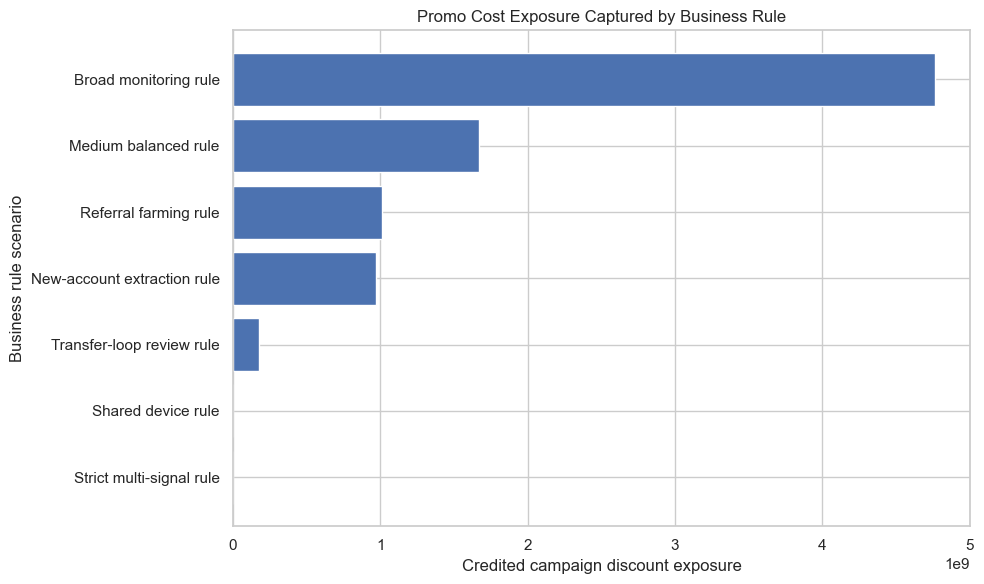

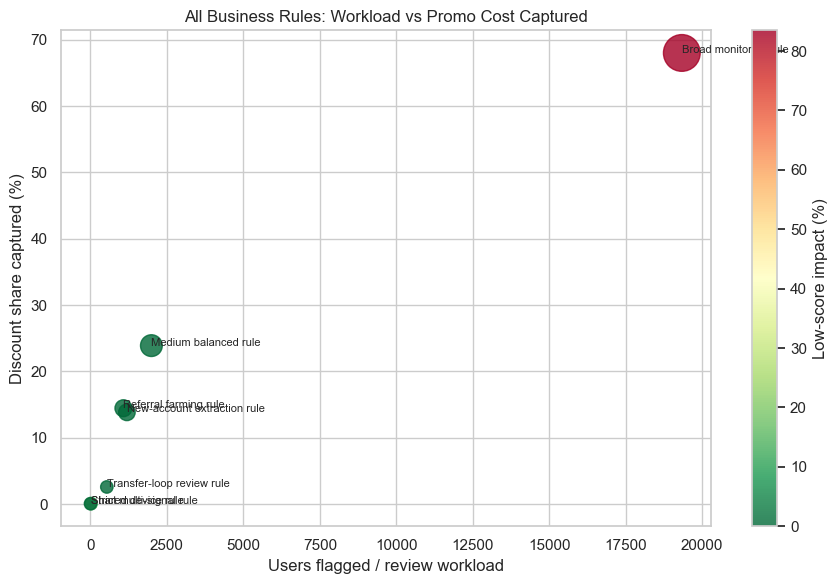

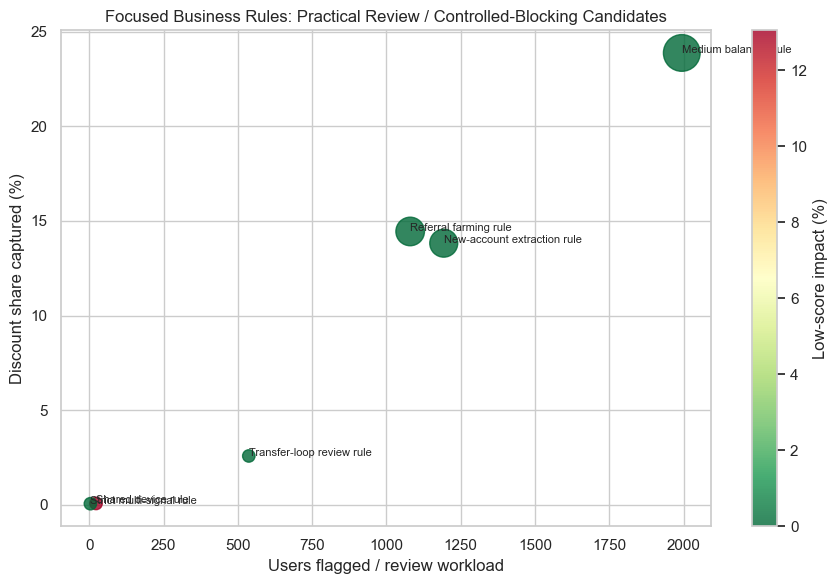

In [8]:
if data_ready and not rule_summary.empty:
    # rule_summary now contains only Python business scenario rules.
    plot_df = rule_summary.sort_values('discount_exposure', ascending=True)

    # Bar chart: promo cost exposure captured by each business rule.
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(plot_df['rule_scenario'], plot_df['discount_exposure'])
    ax.set_title('Promo Cost Exposure Captured by Business Rule')
    ax.set_xlabel('Credited campaign discount exposure')
    ax.set_ylabel('Business rule scenario')
    plt.tight_layout()
    plt.savefig(PY_OUTPUT / 'business_rule_discount_exposure_bar.png', dpi=160, bbox_inches='tight')
    plt.show()

    # Scatter chart: all business rules.
    fig, ax = plt.subplots(figsize=(9, 6))
    scatter = ax.scatter(
        rule_summary['users_flagged'],
        rule_summary['discount_share_pct'],
        s=np.maximum(
            rule_summary['discount_exposure'] / max(rule_summary['discount_exposure'].max(), 1) * 700,
            80
        ),
        c=rule_summary['low_score_impact_pct'],
        cmap='RdYlGn_r',
        alpha=0.8
    )

    for _, row in rule_summary.iterrows():
        ax.annotate(
            row['rule_scenario'][:28],
            (row['users_flagged'], row['discount_share_pct']),
            fontsize=8
        )

    ax.set_title('All Business Rules: Workload vs Promo Cost Captured')
    ax.set_xlabel('Users flagged / review workload')
    ax.set_ylabel('Discount share captured (%)')

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Low-score impact (%)')

    plt.tight_layout()
    plt.savefig(PY_OUTPUT / 'business_rule_tradeoff_scatter.png', dpi=160, bbox_inches='tight')
    plt.show()

    # Focused scatter chart: exclude broad monitoring to compare operational candidates.
    focused_rules = rule_summary[rule_summary['rule_scenario'] != 'Broad monitoring rule'].copy()

    if not focused_rules.empty:
        fig, ax = plt.subplots(figsize=(9, 6))
        scatter = ax.scatter(
            focused_rules['users_flagged'],
            focused_rules['discount_share_pct'],
            s=np.maximum(
                focused_rules['discount_exposure'] / max(focused_rules['discount_exposure'].max(), 1) * 700,
                80
            ),
            c=focused_rules['low_score_impact_pct'],
            cmap='RdYlGn_r',
            alpha=0.8
        )

        for _, row in focused_rules.iterrows():
            ax.annotate(
                row['rule_scenario'][:28],
                (row['users_flagged'], row['discount_share_pct']),
                fontsize=8
            )

        ax.set_title('Focused Business Rules: Practical Review / Controlled-Blocking Candidates')
        ax.set_xlabel('Users flagged / review workload')
        ax.set_ylabel('Discount share captured (%)')

        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Low-score impact (%)')

        plt.tight_layout()
        plt.savefig(PY_OUTPUT / 'focused_business_rule_tradeoff_scatter.png', dpi=160, bbox_inches='tight')
        plt.show()


The trade-off charts compare the fixed business scenario rules. They show which rules capture meaningful promo exposure, which rules create too much review workload, and which rules affect many low-score users.

However, each rule depends on threshold choices such as 500K discount, 20 invitees, or 3 transfer loops. The next section tests stricter and looser thresholds to check whether these thresholds are reasonable.


## Sensitivity Analysis

The business rule scenarios use specific thresholds such as 500K discount, 20 invitees, or 3 transfer loops. Sensitivity analysis checks whether those thresholds are reasonable.

This section tests stricter and looser threshold combinations and compares:

- users flagged
- promo cost captured
- low-score users impacted

The goal is to understand the trade-off between capturing more promo exposure and avoiding overly broad rules.

In [9]:
def sensitivity_grid(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    total_users = len(df)
    total_discount = df['credited_campaign_discount_success_only'].sum()

    # New-account extraction sensitivity.
    for immediate_threshold in [200_000, 500_000, 1_000_000]:
        for row_threshold in [5, 10, 20]:
            mask = (
                (df['immediate_discount_0_1_day'] >= immediate_threshold)
                & (df['immediate_discount_rows_0_1_day'] >= row_threshold)
            )
            flagged = df[mask]

            low_score_users = flagged[flagged['suspicion_score'] < 3]

            rows.append({
                'rule_family': 'new_account_extraction',
                'threshold_1_name': 'immediate_discount_0_1_day',
                'threshold_1_value': immediate_threshold,
                'threshold_2_name': 'immediate_discount_rows_0_1_day',
                'threshold_2_value': row_threshold,
                'users_flagged': len(flagged),
                'user_share_pct': len(flagged) / total_users * 100 if total_users else 0,
                'discount_exposure': flagged['credited_campaign_discount_success_only'].sum(),
                'discount_share_pct': flagged['credited_campaign_discount_success_only'].sum() / total_discount * 100 if total_discount else 0,
                'low_score_users_impacted': len(low_score_users),
            })

    # Referral farming sensitivity.
    for invitee_threshold in [6, 20, 50, 100]:
        for discount_threshold in [100_000, 500_000, 1_000_000]:
            mask = (
                (df['total_invitees'] >= invitee_threshold)
                & (df['credited_campaign_discount_success_only'] >= discount_threshold)
            )
            flagged = df[mask]

            low_score_users = flagged[flagged['suspicion_score'] < 3]

            rows.append({
                'rule_family': 'referral_farming',
                'threshold_1_name': 'total_invitees',
                'threshold_1_value': invitee_threshold,
                'threshold_2_name': 'credited_campaign_discount_success_only',
                'threshold_2_value': discount_threshold,
                'users_flagged': len(flagged),
                'user_share_pct': len(flagged) / total_users * 100 if total_users else 0,
                'discount_exposure': flagged['credited_campaign_discount_success_only'].sum(),
                'discount_share_pct': flagged['credited_campaign_discount_success_only'].sum() / total_discount * 100 if total_discount else 0,
                'low_score_users_impacted': len(low_score_users),
            })

    # Transfer-loop sensitivity.
    for loop_threshold in [1, 3, 18]:
        for discount_threshold in [100_000, 500_000, 1_000_000]:
            mask = (
                (df['transfer_loop_count'] >= loop_threshold)
                & (df['credited_campaign_discount_success_only'] >= discount_threshold)
            )
            flagged = df[mask]

            low_score_users = flagged[flagged['suspicion_score'] < 3]

            rows.append({
                'rule_family': 'transfer_loop',
                'threshold_1_name': 'transfer_loop_count',
                'threshold_1_value': loop_threshold,
                'threshold_2_name': 'credited_campaign_discount_success_only',
                'threshold_2_value': discount_threshold,
                'users_flagged': len(flagged),
                'user_share_pct': len(flagged) / total_users * 100 if total_users else 0,
                'discount_exposure': flagged['credited_campaign_discount_success_only'].sum(),
                'discount_share_pct': flagged['credited_campaign_discount_success_only'].sum() / total_discount * 100 if total_discount else 0,
                'low_score_users_impacted': len(low_score_users),
            })

    out = pd.DataFrame(rows)

    out['low_score_impact_pct'] = np.where(
        out['users_flagged'] > 0,
        out['low_score_users_impacted'] / out['users_flagged'] * 100,
        0
    )

    return out


if data_ready:
    sensitivity = sensitivity_grid(scored)

    display(
        sensitivity
        .sort_values(['discount_share_pct', 'users_flagged'], ascending=[False, False])
        .head(20)
    )
else:
    sensitivity = pd.DataFrame()

,rule_family,threshold_1_name,threshold_1_value,threshold_2_name,threshold_2_value,users_flagged,user_share_pct,discount_exposure,discount_share_pct,low_score_users_impacted,low_score_impact_pct
9,referral_farming,total_invitees,6,credited_campaign_discount_success_only,100000,4317,5.009864,2437035000,34.795126,2137,49.501969
10,referral_farming,total_invitees,6,credited_campaign_discount_success_only,500000,2273,2.637809,1862325000,26.589620,276,12.142543
0,new_account_extraction,immediate_discount_0_1_day,200000,immediate_discount_rows_0_1_day,5,2778,3.223860,1469610000,20.982573,1496,53.851692
12,referral_farming,total_invitees,20,credited_campaign_discount_success_only,100000,1147,1.331090,1030480000,14.712830,0,0.000000
13,referral_farming,total_invitees,20,credited_campaign_discount_success_only,500000,1080,1.253336,1011790000,14.445981,0,0.000000
1,new_account_extraction,immediate_discount_0_1_day,200000,immediate_discount_rows_0_1_day,10,1217,1.412324,980135000,13.994022,14,1.150370
3,new_account_extraction,immediate_discount_0_1_day,500000,immediate_discount_rows_0_1_day,5,1193,1.384473,968360000,13.825903,0,0.000000
4,new_account_extraction,immediate_discount_0_1_day,500000,immediate_discount_rows_0_1_day,10,1193,1.384473,968360000,13.825903,0,0.000000
21,transfer_loop,transfer_loop_count,1,credited_campaign_discount_success_only,100000,2866,3.325984,751515000,10.729866,1843,64.305652
11,referral_farming,total_invitees,6,credited_campaign_discount_success_only,1000000,533,0.618545,545575000,7.789527,0,0.000000


The selected-threshold table shows threshold combinations that meet the screening criteria. However, final business rules may use slightly stricter thresholds when the business prefers stronger evidence over marginally higher promo-cost capture.

For example, the sensitivity grid shows that lower discount thresholds can capture slightly more exposure, but the final referral and new-account rules keep the 500K threshold to preserve clearer business explainability and stronger risk confidence.

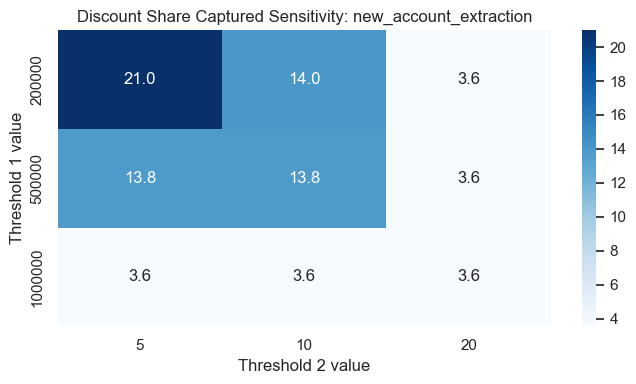

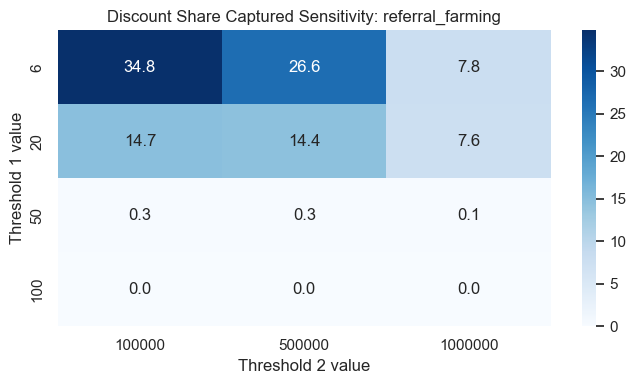

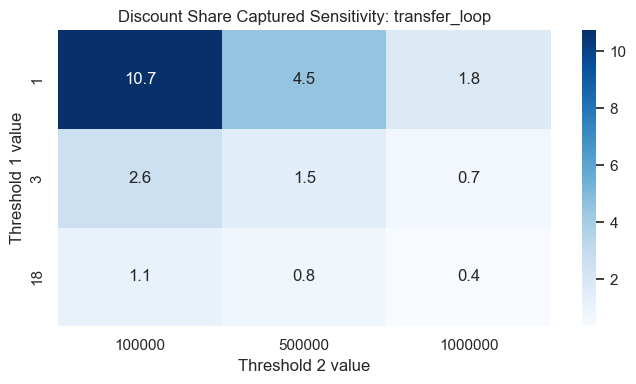

In [10]:
if data_ready and not sensitivity.empty:
    for family in sensitivity['rule_family'].unique():
        family_df = sensitivity[sensitivity['rule_family'] == family]
        pivot = family_df.pivot_table(
            index='threshold_1_value',
            columns='threshold_2_value',
            values='discount_share_pct',
            aggfunc='mean',
        )
        fig, ax = plt.subplots(figsize=(7, 4))
        if HAS_SEABORN:
            sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', ax=ax)
        else:
            ax.imshow(pivot.values, cmap='Blues')
            ax.set_xticks(range(len(pivot.columns)), pivot.columns)
            ax.set_yticks(range(len(pivot.index)), pivot.index)
        ax.set_title(f'Discount Share Captured Sensitivity: {family}')
        ax.set_xlabel('Threshold 2 value')
        ax.set_ylabel('Threshold 1 value')
        plt.tight_layout()
        plt.savefig(PY_OUTPUT / f'sensitivity_{family}.png', dpi=160, bbox_inches='tight')
        plt.show()

The heatmaps show that looser thresholds usually capture more promo cost, but they may also increase low-score user impact. Stricter thresholds are cleaner but may miss too much promo exposure.

These results support the final rule recommendations by showing why balanced thresholds are preferred over the broadest possible thresholds.

The sensitivity grid is used as supporting evidence for threshold selection. This section selects candidate threshold combinations that:

- capture at least 5% of promo cost
- keep low-score impact at or below 5%
- avoid flagging more than 3.5% of users

These screening criteria are **not fraud truth thresholds**. They are practical business filters: a useful rule should capture meaningful exposure, avoid affecting many low-score users, and keep review workload manageable.

The selected thresholds help justify why final business rules use balanced thresholds instead of the loosest thresholds.


In [11]:
if data_ready and not sensitivity.empty:
    candidate_thresholds = sensitivity[
        (sensitivity['discount_share_pct'] >= 5)
        & (sensitivity['low_score_impact_pct'] <= 5)
        & (sensitivity['user_share_pct'] <= 3.5)
    ].copy()

    selected_thresholds = (
        candidate_thresholds
        .sort_values(
            ['rule_family', 'discount_share_pct', 'low_score_impact_pct', 'users_flagged'],
            ascending=[True, False, True, True]
        )
        .groupby('rule_family', as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    display(selected_thresholds[[
        'rule_family',
        'threshold_1_name',
        'threshold_1_value',
        'threshold_2_name',
        'threshold_2_value',
        'users_flagged',
        'user_share_pct',
        'discount_exposure',
        'discount_share_pct',
        'low_score_users_impacted',
        'low_score_impact_pct'
    ]])
else:
    selected_thresholds = pd.DataFrame()

,rule_family,threshold_1_name,threshold_1_value,threshold_2_name,threshold_2_value,users_flagged,user_share_pct,discount_exposure,discount_share_pct,low_score_users_impacted,low_score_impact_pct
0,new_account_extraction,immediate_discount_0_1_day,200000,immediate_discount_rows_0_1_day,10,1217,1.412324,980135000,13.994022,14,1.15037
1,referral_farming,total_invitees,20,credited_campaign_discount_success_only,100000,1147,1.331090,1030480000,14.712830,0,0.00000


## Recommendation Logic

This section converts the business rule simulation into action labels.

A rule is more attractive when it captures meaningful promo-cost exposure with manageable workload and low low-score impact.

Because the dataset does not contain confirmed fraud labels, this section does not calculate confirmed false alarms. Instead, low-score impact is used as a proxy for over-flagging risk: users affected by a rule but not strongly suspicious under the baseline scoring framework.

The recommendation logic uses the business rule summary as the main decision table. The selected-threshold section is used as supporting evidence to justify why balanced thresholds are preferred over loose thresholds.


In [12]:
if data_ready and not rule_summary.empty:
    recommendations = rule_summary.copy()

    recommendations['workload_band'] = pd.cut(
        recommendations['users_flagged'],
        bins=[-1, 100, 1000, 5000, np.inf],
        labels=['Low', 'Medium', 'High', 'Very high']
    )

    recommendations['discount_capture_band'] = pd.cut(
        recommendations['discount_share_pct'],
        bins=[-1, 5, 15, 30, 100],
        labels=['Low', 'Medium', 'High', 'Very high']
    )

    recommendations['overflagging_risk_band'] = pd.cut(
        recommendations['low_score_impact_pct'],
        bins=[-1, 5, 15, 30, 100],
        labels=['Low', 'Medium', 'High', 'Very high']
    )

    def business_use(row):
        if row['low_score_impact_pct'] <= 5 and row['discount_share_pct'] >= 10:
            return 'Candidate for controlled blocking test or high-priority review'

        if row['low_score_impact_pct'] <= 15 and row['discount_share_pct'] >= 5:
            return 'Candidate for manual review queue'

        if row['users_flagged'] > 5000 or row['low_score_impact_pct'] > 30:
            return 'Monitoring only; too broad for direct blocking'

        return 'Supporting rule; combine with other signals'

    recommendations['business_use'] = recommendations.apply(business_use, axis=1)

    display(recommendations[[
        'rule_scenario',
        'rule_definition',
        'users_flagged',
        'user_share_pct',
        'discount_exposure',
        'discount_share_pct',
        'low_score_users_impacted',
        'low_score_impact_pct',
        'workload_band',
        'discount_capture_band',
        'overflagging_risk_band',
        'business_use'
    ]])

else:
    recommendations = pd.DataFrame()


,rule_scenario,rule_definition,users_flagged,user_share_pct,discount_exposure,discount_share_pct,low_score_users_impacted,low_score_impact_pct,workload_band,discount_capture_band,overflagging_risk_band,business_use
2,Broad monitoring rule,credited discount >= 100K or shared-device sig...,19332,22.434722,4764205000,68.021639,16137,83.472998,Very high,Very high,Very high,Monitoring only; too broad for direct blocking
1,Medium balanced rule,credited discount >= 500K and at least 2 total...,1994,2.314030,1673050000,23.887218,0,0.000000,High,High,Low,Candidate for controlled blocking test or high...
3,Referral farming rule,total invitees >= 20 and credited discount >= ...,1080,1.253336,1011790000,14.445981,0,0.000000,High,Medium,Low,Candidate for controlled blocking test or high...
4,New-account extraction rule,immediate discount 0-1 day >= 500K and immedia...,1193,1.384473,968360000,13.825903,0,0.000000,High,Medium,Low,Candidate for controlled blocking test or high...
5,Transfer-loop review rule,transfer loop count >= 3 and credited discount...,537,0.623187,180165000,2.572332,0,0.000000,Medium,Low,Low,Supporting rule; combine with other signals
6,Shared device rule,max users per device >= 10,23,0.026691,4240000,0.060537,3,13.043478,Low,Low,Medium,Supporting rule; combine with other signals
0,Strict multi-signal rule,"credited discount >= 500K, immediate discount ...",4,0.004642,3295000,0.047045,0,0.000000,Low,Low,Low,Supporting rule; combine with other signals


The recommendation table translates technical rule results into business actions.

Rules with meaningful promo-cost capture and low low-score impact can be considered for controlled blocking tests or high-priority review. Rules that flag too many users or affect many low-score users should be used for monitoring only. Rules with low standalone coverage should be treated as supporting signals.

**Final business interpretation**

| Rule | Main result | Recommended use |
|---|---|---|
| Broad monitoring rule | Captures the most promo exposure but flags too many users | Monitoring only |
| Medium balanced rule | Best balance of promo exposure and low-score impact | Controlled blocking test / high-priority review |
| Referral farming rule | Explainable rule tied to invite abuse and high promo value | High-priority review |
| New-account extraction rule | Captures fast reward extraction after account creation | High-priority review |
| Transfer-loop review rule | Useful investigation signal | Manual review |
| Shared device rule | Low standalone coverage | Supporting signal |
| Strict multi-signal rule | Strong evidence but very low coverage | Supporting signal |


## Export Python Outputs

These outputs are useful for Power BI and the final report:

- `python_business_rule_simulation_summary.csv`
- `python_business_rule_recommendations.csv`
- `python_rule_sensitivity_grid.csv`
- `python_selected_thresholds.csv`
- `python_sql_baseline_rule_summary.csv`
- `python_sql_reconciliation_summary.csv`
- `python_rebuilt_suspicious_users_full.csv`
- `result.xlsx` with only `userID` and `reason`

In [13]:
if data_ready:
    # Main business outputs.
    rule_summary.to_csv(PY_OUTPUT / 'python_business_rule_simulation_summary.csv', index=False)
    recommendations.to_csv(PY_OUTPUT / 'python_business_rule_recommendations.csv', index=False)

    # Validation and reconciliation outputs.
    if 'sql_baseline_rule_summary' in globals() and not sql_baseline_rule_summary.empty:
        sql_baseline_rule_summary.to_csv(PY_OUTPUT / 'python_sql_baseline_rule_summary.csv', index=False)

    if 'sql_reconciliation_summary' in globals() and not sql_reconciliation_summary.empty:
        sql_reconciliation_summary.to_csv(PY_OUTPUT / 'python_sql_reconciliation_summary.csv', index=False)

    # Sensitivity outputs.
    sensitivity.to_csv(PY_OUTPUT / 'python_rule_sensitivity_grid.csv', index=False)

    if 'selected_thresholds' in globals() and not selected_thresholds.empty:
        selected_thresholds.to_csv(PY_OUTPUT / 'python_selected_thresholds.csv', index=False)

    # Rebuilt suspicious users.
    suspicious_baseline.to_csv(PY_OUTPUT / 'python_rebuilt_suspicious_users_full.csv', index=False)

    # Final assessment deliverable.
    result_path = DATA_OUTPUT / 'result.xlsx'
    result_csv_fallback = DATA_OUTPUT / 'result.csv'
    result_cols = suspicious_baseline[['userID', 'reason']].copy()

    try:
        result_cols.to_excel(result_path, index=False)
        result_message = f'Created Excel deliverable: {result_path}'
    except ModuleNotFoundError as exc:
        result_cols.to_csv(result_csv_fallback, index=False)
        result_message = (
            f'Could not create result.xlsx because the current Python kernel is missing an Excel writer dependency: {exc}.\n'
            f'Saved CSV fallback instead: {result_csv_fallback}\n'
            'Install openpyxl in this notebook environment with: pip install openpyxl, then rerun this cell.'
        )

    print('Exported:')
    print('-', PY_OUTPUT / 'python_business_rule_simulation_summary.csv')
    print('-', PY_OUTPUT / 'python_business_rule_recommendations.csv')
    print('-', PY_OUTPUT / 'python_rule_sensitivity_grid.csv')

    if 'selected_thresholds' in globals() and not selected_thresholds.empty:
        print('-', PY_OUTPUT / 'python_selected_thresholds.csv')

    if 'sql_baseline_rule_summary' in globals() and not sql_baseline_rule_summary.empty:
        print('-', PY_OUTPUT / 'python_sql_baseline_rule_summary.csv')

    if 'sql_reconciliation_summary' in globals() and not sql_reconciliation_summary.empty:
        print('-', PY_OUTPUT / 'python_sql_reconciliation_summary.csv')

    print('-', PY_OUTPUT / 'python_rebuilt_suspicious_users_full.csv')
    print('-', result_message)

Exported:
- C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\python_rule_simulation\python_business_rule_simulation_summary.csv
- C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\python_rule_simulation\python_business_rule_recommendations.csv
- C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\python_rule_simulation\python_rule_sensitivity_grid.csv
- C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\python_rule_simulation\python_selected_thresholds.csv
- C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\python_rule_simulation\python_sql_baseline_rule_summary.csv
- C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\python_rule_simulation\python_sql_reconciliation_summary.csv
- C:\Users\phanh\data_analysis\p_projects\zalo\zalo_private\data\output\python_rule_simulation\python_rebuilt_suspicious_users_full.csv
- Created Excel deliverable: C:\Users\phanh\data_analysis\p_

## Final Interpretation

This notebook uses Python as a rule-simulation and decision-support layer after SQL.

SQL created the source-of-truth user-level features and the baseline suspicious-user framework. Python then tested different Risk Engine rule scenarios using those features. Each rule was evaluated by the number of users flagged, the share of promo cost captured, the average promo value per flagged user, and the number of low-score users impacted.

The results show that broad rules can capture the largest share of promo exposure, but they also create high review workload and higher over-flagging risk. These rules are more suitable for monitoring than direct blocking.

The medium balanced rule provides the strongest operational balance. It captures meaningful promo-cost exposure while keeping low-score impact low under the baseline framework. This makes it a good candidate for high-priority review or a controlled blocking test.

Referral farming and new-account extraction rules are also useful because they are easy to explain and directly map to common promotion-abuse patterns: invite farming and fast reward extraction after account creation.

Transfer-loop and shared-device rules are better treated as supporting signals. They add useful context, but they should usually be combined with other evidence before action is taken.

Overall, the simulation supports a layered prevention strategy:

1. Use broad rules for monitoring and early warning.
2. Use balanced and explainable rules for high-priority review.
3. Use strict multi-signal rules for controlled blocking tests.
4. Keep supporting signals available for investigation and rule refinement.